## Imports & Configurations

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import pandas as pd
from IPython.display import display
import os
import warnings
warnings.filterwarnings('ignore')

qso_colors = np.load(os.path.join(os.getcwd(), '..', 'Outputs', 'quasar_colors.npz'))
r_i_clean_qso = qso_colors['r_i_clean_qso']
g_r_clean_qso = qso_colors['g_r_clean_qso']
u_g_clean_qso = qso_colors['u_g_clean_qso']
i_z_clean_qso = qso_colors['i_z_clean_qso']
Z = qso_colors['Z']

## Optical Color-Color Diagrams of Quasars

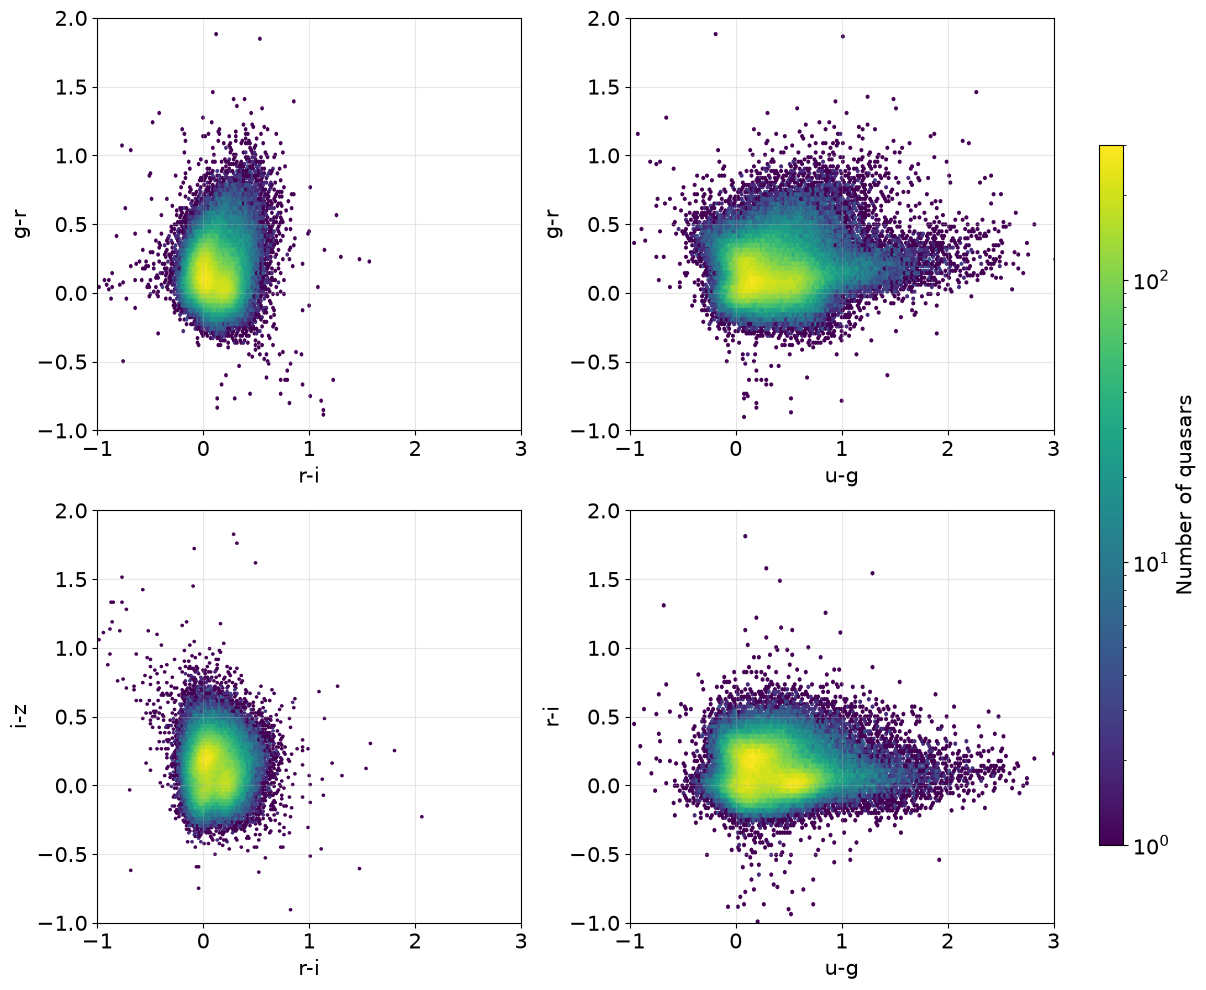

In [10]:
color_pairs = [
    (r_i_clean_qso, g_r_clean_qso, 'r-i', 'g-r'),
    (u_g_clean_qso, g_r_clean_qso, 'u-g', 'g-r'),
    (r_i_clean_qso, i_z_clean_qso, 'r-i', 'i-z'),
    (u_g_clean_qso, r_i_clean_qso, 'u-g', 'r-i')
]

fig, axes = plt.subplots(2,2,figsize=(12,10),sharex=False,sharey=False)

axes = axes.flatten()

for ax, (x, y, xlabel, ylabel) in zip(axes, color_pairs):
    hb = ax.hexbin(x,y,gridsize=200,cmap='viridis',mincnt=1,norm=LogNorm())
    ax.set_xlim(-1,3)
    ax.set_ylim(-1,2)
    ax.set_xlabel(xlabel,fontsize=15)
    ax.set_ylabel(ylabel,fontsize=15)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.grid(alpha=0.3)
cbar_ax=fig.add_axes([0.92, 0.15, 0.02, 0.7])  
fig.colorbar(hb,cax=cbar_ax,label='Number of quasars')
cbar_ax.yaxis.label.set_size(15)
cbar_ax.tick_params(labelsize=15)

#fig.suptitle('Optical Color-Color Diagrams of Quasars',fontsize=15)

plt.tight_layout(rect=[0, 0, 0.9, 1])
plt.show()

## Optical Color-Color Diagrams in Different Redshift Slices

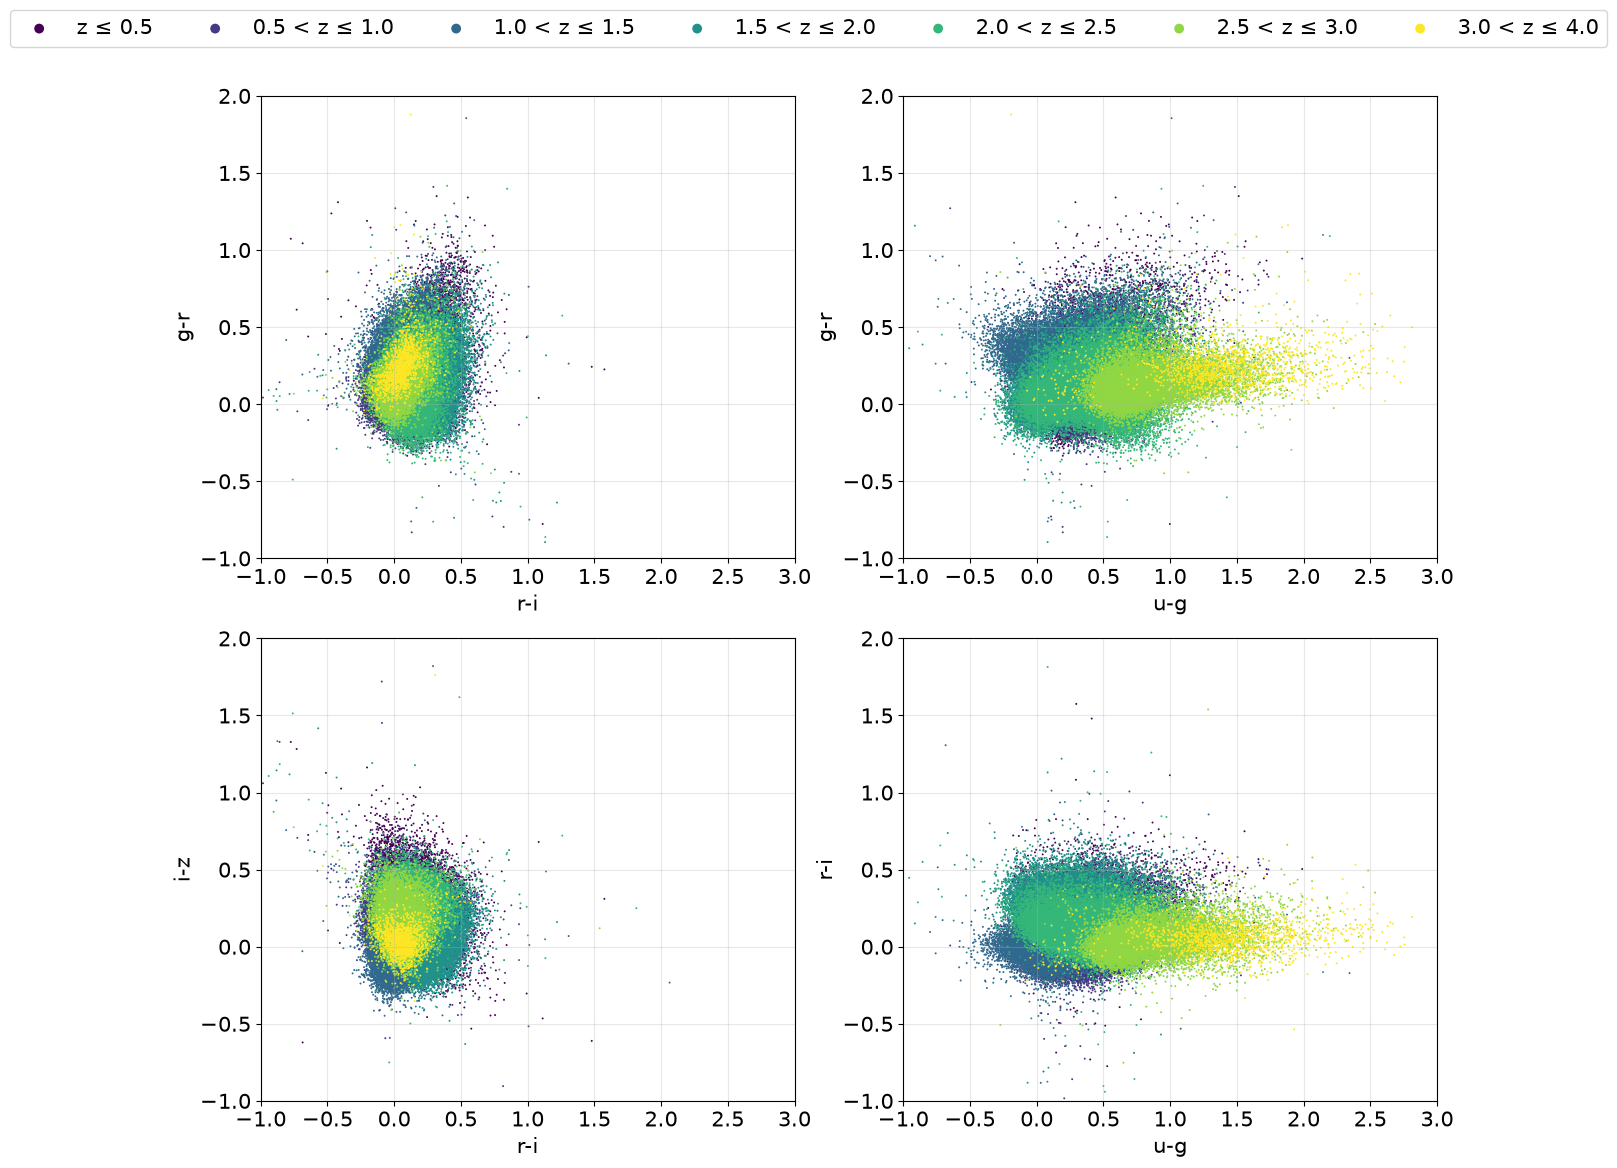

In [11]:
z_1=Z<=0.5
z_2=(Z>0.5)&(Z<=1.0)
z_3=(Z>1.0)&(Z<=1.5)
z_4=(Z>1.5)&(Z<=2.0)
z_5=(Z>2.0)&(Z<=2.5)
z_6=(Z>2.5)&(Z<=3.0)
z_7=(Z>3.0)&(Z<=4)

z_samples = [
    ('z ≤ 0.5', z_1),
    ('0.5 < z ≤ 1.0', z_2),
    ('1.0 < z ≤ 1.5', z_3),
    ('1.5 < z ≤ 2.0', z_4),
    ('2.0 < z ≤ 2.5', z_5),
    ('2.5 < z ≤ 3.0', z_6),
    ('3.0 < z ≤ 4.0', z_7)
]

slice_colors = plt.cm.viridis(np.linspace(0, 1, len(z_samples)))

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for ax, (x, y, xlabel, ylabel) in zip(axes, color_pairs):

    for (label, mask), color in zip(z_samples, slice_colors):
        ax.scatter(x[mask],y[mask],s=2,color=color,edgecolors='none',label=label)
    ax.set_xlabel(xlabel, fontsize=15)
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_xlim(-1,3)
    ax.set_ylim(-1,2)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='both', which='major', labelsize=15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.067), ncol=7, fontsize=15, markerscale=5)

#fig.suptitle('Optical Color-Color Diagrams in Different Redshift Slices',fontsize=15)

plt.tight_layout()
plt.show()

## Evolution of Quasar Colors with Redshift

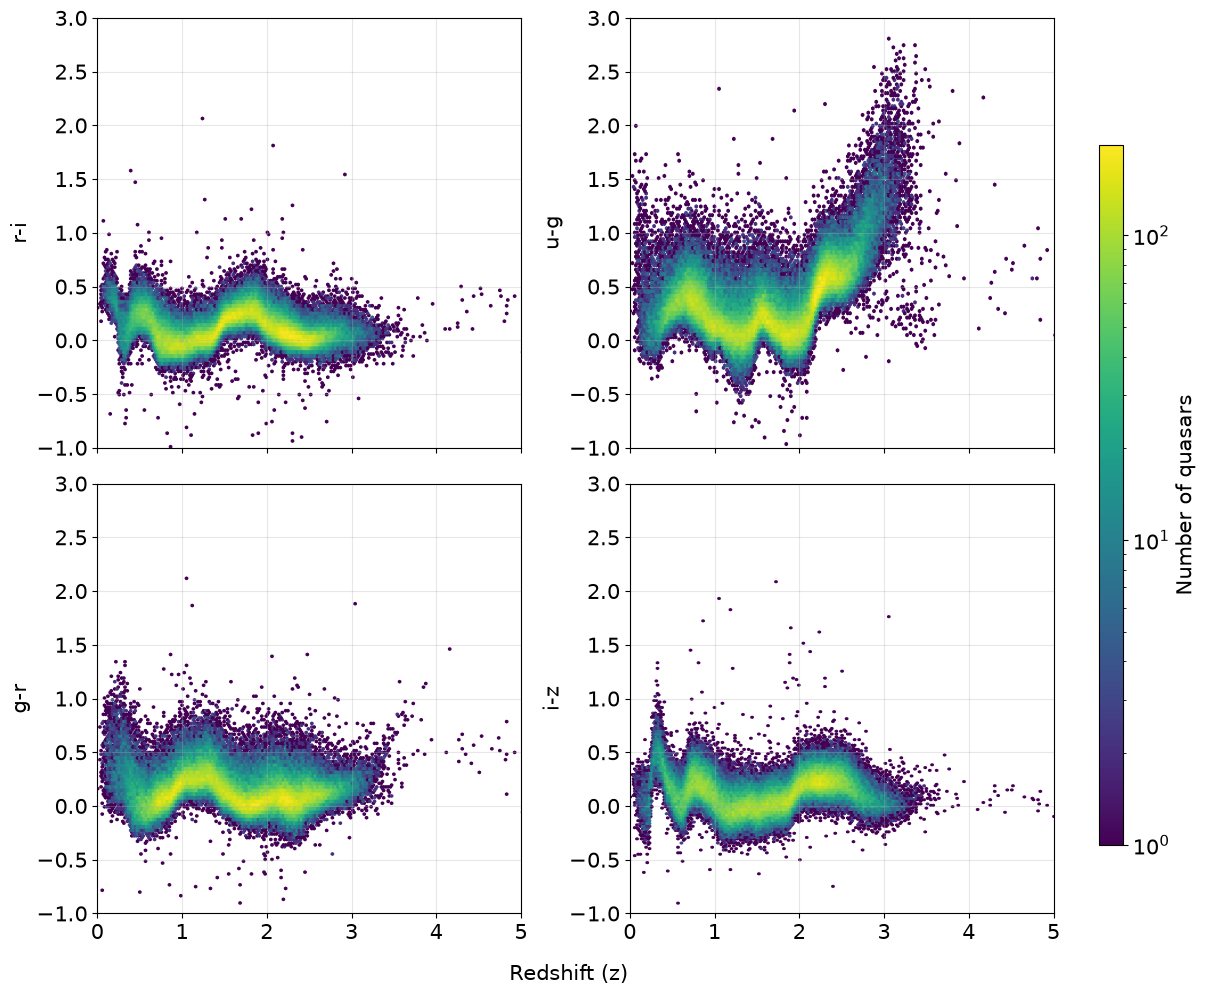

In [12]:
color_redshift = [
    (r_i_clean_qso, 'r-i'),
    (u_g_clean_qso, 'u-g'),
    (g_r_clean_qso, 'g-r'),
    (i_z_clean_qso, 'i-z')
]

fig, axes = plt.subplots(2,2,figsize=(12,10),sharex=True,sharey=False)
axes = axes.flatten()

for ax, (color, ylabel) in zip(axes, color_redshift):
    hb = ax.hexbin(Z,color,gridsize=200,cmap='viridis',mincnt=1,norm=LogNorm())
    ax.set_xlim(0, 5)
    ax.set_ylim(-1, 3)
    ax.set_ylabel(ylabel,fontsize=15)
    ax.tick_params(axis='both', which='major', labelsize=15)
    ax.grid(alpha=0.3)
cbar_ax=fig.add_axes([0.92, 0.15, 0.02, 0.7])  
fig.colorbar(hb,cax=cbar_ax,label='Number of quasars')
cbar_ax.yaxis.label.set_size(15)
cbar_ax.tick_params(labelsize=15)
fig.supxlabel('Redshift (z)',fontsize=15,x=0.478)
#fig.suptitle( 'Evolution of Quasar Colors with Redshift',fontsize=15)

plt.tight_layout(rect=[0, 0, 0.90, 1])
plt.show()

## Color Statistics

In [13]:
z_bins = np.array([0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 7.0])
z_labels = ['0-0.5', '0.5-1.0', '1.0-1.5', '1.5-2.0', '2.0-2.5', '2.5-3.0', '3.0-4.0', '>4.0']
z_masks = []

for i, (low, high) in enumerate(zip(z_bins[:-1], z_bins[1:])):
    if i == 0:
        mask = (Z >= low) & (Z <= high)
    else:
        mask = (Z > low) & (Z <= high)

    z_masks.append(mask)

def color_statistics(color, color_name):

    rows = []

    for label, mask in zip(z_labels, z_masks):

        rows.append({
            'Redshift': label,
            'N': len(color[mask]),
            'Median': np.median(color[mask]),
            'Std': np.std(color[mask]),
            '16th': np.percentile(color[mask], 16),
            '84th': np.percentile(color[mask], 84)
        })

    df = pd.DataFrame(rows)

    df['Δ Median'] = df['Median'].diff()

    styled_df = (
        df.style
        .set_caption(f'{color_name} Color Statistics by Redshift')
        .set_table_styles([
            {'selector': 'caption', 'props': [('font-size', '15px'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
            {'selector': 'td', 'props': [('text-align', 'center')]}
        ])
        .set_properties(**{'width': '110px'})
        .format({
            'Median': '{:.3f}',
            'Std': '{:.3f}',
            '16th': '{:.3f}',
            '84th': '{:.3f}',
            'Δ Median': '{:+.3f}'
        })
    )

    return df, styled_df

u_g_df, u_g_table = color_statistics(u_g_clean_qso, 'u-g')
g_r_df, g_r_table = color_statistics(g_r_clean_qso, 'g-r')
r_i_df, r_i_table = color_statistics(r_i_clean_qso, 'r-i')
i_z_df, i_z_table = color_statistics(i_z_clean_qso, 'i-z')

In [14]:
display(u_g_table)
display(g_r_table)
display(r_i_table)
display(i_z_table)

,Redshift,N,Median,Std,16th,84th,Δ Median
0,0-0.5,7332,0.262,0.243,0.096,0.492,+nan
1,0.5-1.0,31255,0.350,0.188,0.184,0.536,+0.089
2,1.0-1.5,32773,0.109,0.196,-0.024,0.307,-0.241
3,1.5-2.0,35690,0.158,0.178,0.016,0.335,+0.049
4,2.0-2.5,39766,0.493,0.242,0.192,0.686,+0.335
5,2.5-3.0,14631,0.757,0.289,0.574,1.111,+0.264
6,3.0-4.0,1409,1.406,0.482,1.049,1.874,+0.649
7,>4.0,21,0.584,0.480,0.258,0.884,-0.822


,Redshift,N,Median,Std,16th,84th,Δ Median
0,0-0.5,7332,0.192,0.255,-0.025,0.479,+nan
1,0.5-1.0,31255,0.096,0.145,-0.026,0.235,-0.096
2,1.0-1.5,32773,0.263,0.137,0.162,0.402,+0.167
3,1.5-2.0,35690,0.063,0.134,-0.029,0.203,-0.200
4,2.0-2.5,39766,0.076,0.140,-0.028,0.212,+0.013
5,2.5-3.0,14631,0.124,0.108,0.041,0.224,+0.048
6,3.0-4.0,1409,0.231,0.160,0.132,0.362,+0.107
7,>4.0,21,0.500,0.281,0.331,0.656,+0.269


,Redshift,N,Median,Std,16th,84th,Δ Median
0,0-0.5,7332,0.216,0.166,0.057,0.375,+nan
1,0.5-1.0,31255,0.039,0.153,-0.087,0.226,-0.178
2,1.0-1.5,32773,0.032,0.108,-0.057,0.143,-0.007
3,1.5-2.0,35690,0.243,0.097,0.165,0.338,+0.211
4,2.0-2.5,39766,0.068,0.103,-0.012,0.175,-0.175
5,2.5-3.0,14631,0.031,0.091,-0.038,0.115,-0.037
6,3.0-4.0,1409,0.058,0.104,-0.035,0.144,+0.027
7,>4.0,21,0.322,0.158,0.110,0.428,+0.264


,Redshift,N,Median,Std,16th,84th,Δ Median
0,0-0.5,7332,0.289,0.200,0.101,0.485,+nan
1,0.5-1.0,31255,0.161,0.139,0.032,0.300,-0.128
2,1.0-1.5,32773,-0.010,0.121,-0.112,0.115,-0.171
3,1.5-2.0,35690,0.041,0.118,-0.062,0.161,+0.051
4,2.0-2.5,39766,0.232,0.100,0.146,0.333,+0.191
5,2.5-3.0,14631,0.157,0.125,0.037,0.285,-0.076
6,3.0-4.0,1409,0.034,0.106,-0.039,0.121,-0.123
7,>4.0,21,0.059,0.078,-0.023,0.146,+0.025


## Export Color Statistics

In [15]:
u_g_df['color'] = 'u-g'
g_r_df['color'] = 'g-r'
r_i_df['color'] = 'r-i'
i_z_df['color'] = 'i-z'

all_color_stats = pd.concat([u_g_df, g_r_df, r_i_df, i_z_df], ignore_index=True)

output_path = os.path.join(os.getcwd(), '..', 'Outputs', 'Quasar_Color_Statistics.csv')
all_color_stats.to_csv(output_path, index=False)
all_color_stats

,Redshift,N,Median,Std,16th,84th,Δ Median,color
0,0-0.5,7332,0.261681,0.242523,0.096229,0.491542,NaN,u-g
1,0.5-1.0,31255,0.350208,0.187869,0.184339,0.535724,0.088528,u-g
2,1.0-1.5,32773,0.108793,0.195650,-0.024175,0.306689,-0.241415,u-g
3,1.5-2.0,35690,0.157544,0.177533,0.015581,0.335292,0.048751,u-g
4,2.0-2.5,39766,0.492872,0.241592,0.192448,0.685576,0.335328,u-g
5,2.5-3.0,14631,0.756712,0.289273,0.573839,1.111446,0.263840,u-g
6,3.0-4.0,1409,1.406153,0.482346,1.049374,1.874223,0.649441,u-g
7,>4.0,21,0.584244,0.479588,0.258434,0.883841,-0.821909,u-g
8,0-0.5,7332,0.192033,0.254953,-0.024827,0.479134,NaN,g-r
9,0.5-1.0,31255,0.096205,0.144730,-0.026299,0.234547,-0.095828,g-r


## Color Evolution

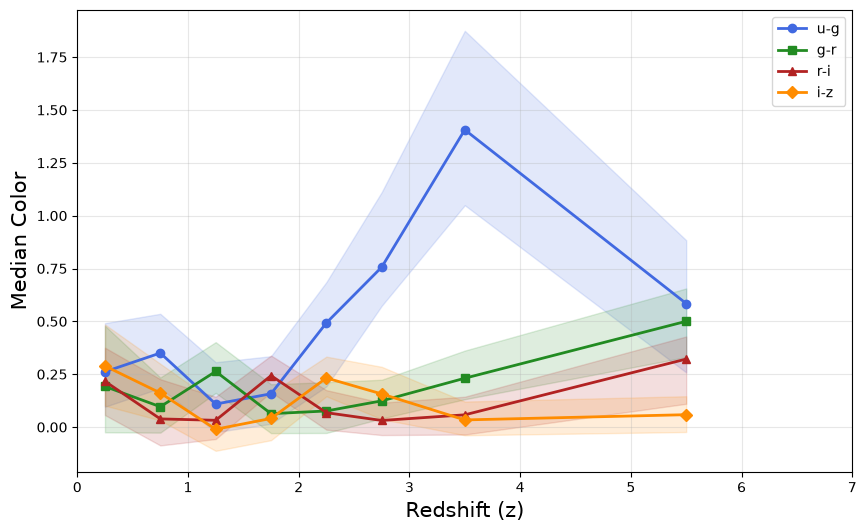

In [16]:
z_mid = (z_bins[:-1] + z_bins[1:]) / 2

plt.figure(figsize=(10,6))

plt.plot(z_mid, u_g_df['Median'],marker='o',linewidth=2,color='royalblue',label='u-g')
plt.fill_between(z_mid,u_g_df['16th'],u_g_df['84th'],color='royalblue',alpha=0.15)

plt.plot(z_mid, g_r_df['Median'],marker='s',linewidth=2,color='forestgreen',label='g-r')
plt.fill_between(z_mid,g_r_df['16th'],g_r_df['84th'],color='forestgreen',alpha=0.15)

plt.plot(z_mid, r_i_df['Median'],marker='^',linewidth=2,color='firebrick',label='r-i')
plt.fill_between(z_mid,r_i_df['16th'],r_i_df['84th'],color='firebrick',alpha=0.15)

plt.plot(z_mid, i_z_df['Median'],marker='D',linewidth=2,color='darkorange',label='i-z')
plt.fill_between(z_mid,i_z_df['16th'],i_z_df['84th'],color='darkorange',alpha=0.15)

plt.xlabel('Redshift (z)', fontsize=15)
plt.ylabel('Median Color', fontsize=15)
plt.xlim(0,7)
plt.grid(alpha=0.3)
plt.legend()

plt.show()